In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler, OrdinalEncoder
from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
import joblib

In [4]:
df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [6]:
categorical_columns = selector(dtype_include=object)(df)

In [7]:
for c in categorical_columns:
  print(c, df[c].unique())

person_gender ['female' 'male']
person_education ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
person_home_ownership ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
previous_loan_defaults_on_file ['No' 'Yes']


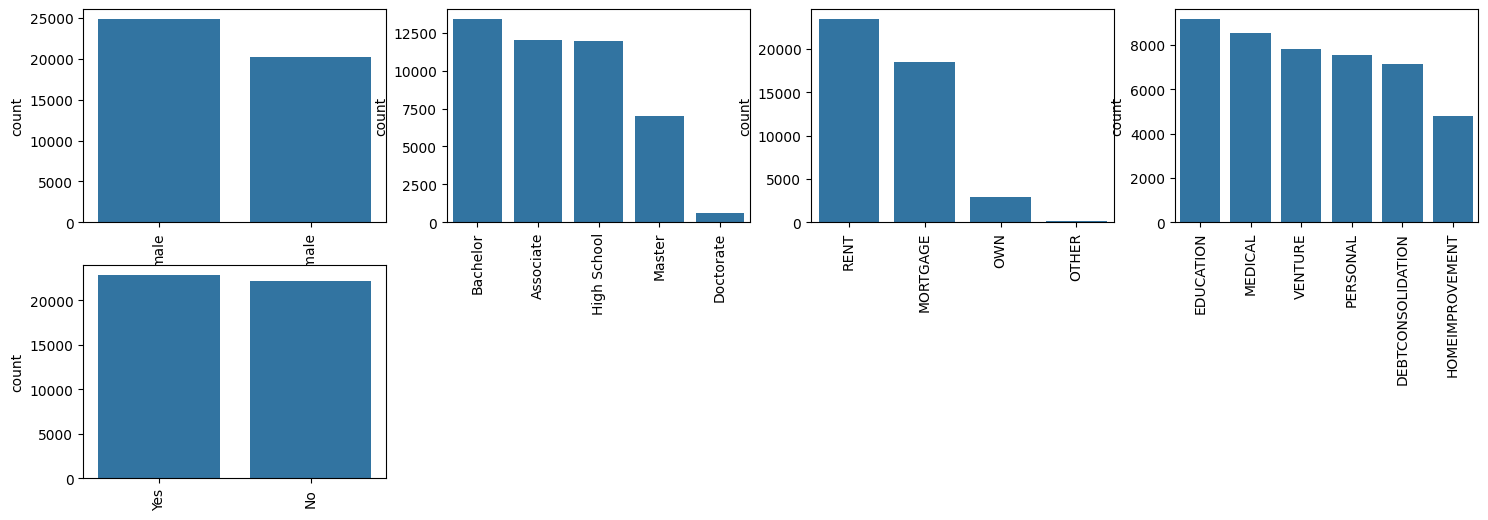

In [8]:
index = 1
plt.figure(figsize=(18,36))

for col in categorical_columns:
  y_axis = df[col].value_counts()
  plt.subplot(11,4,index)
  plt.xticks(rotation=90)
  sns.barplot(x=list(y_axis.index), y=y_axis)
  index +=1

In [9]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

In [10]:
numerical_columns = selector(dtype_exclude=object)(X)

In [11]:
# Detecting which of the numerical columns have outlier
def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    has_outliers = ((data < lower_bound) | (data > upper_bound)).any()

    return has_outliers

In [12]:
for n in numerical_columns:
  print(n, detect_outliers_iqr(df[n]))

person_age True
person_income True
person_emp_exp True
loan_amnt True
loan_int_rate True
loan_percent_income True
cb_person_cred_hist_length True
credit_score True


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
cat_without_order = ['person_home_ownership', 'loan_intent']
cat_with_order = ['person_gender', 'previous_loan_defaults_on_file']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_columns),
        ('cat_without_order', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_without_order),
        ('cat_education', OrdinalEncoder(categories=[['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]), ['person_education']),
        ('cat_with_order', OrdinalEncoder(), cat_with_order)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [15]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train_processed, y_train)
y_pred = classifier.predict(X_test_processed)

accuracy_forest = accuracy_score(y_test, y_pred)
classification_report_forest = classification_report(y_test, y_pred)
confusion_matrix_forest = confusion_matrix(y_test, y_pred)

print('Accuracy:', accuracy_forest)
print('Classification Report:', classification_report_forest)
print('Confusion matrix:', confusion_matrix_forest)

Accuracy: 0.9308888888888889
Classification Report:               precision    recall  f1-score   support

           0       0.94      0.97      0.96      6990
           1       0.89      0.78      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.88      0.90      9000
weighted avg       0.93      0.93      0.93      9000

Confusion matrix: [[6805  185]
 [ 437 1573]]


In [16]:
lr = LogisticRegression()
lr.fit(X_train_processed, y_train)
y_pred = lr.predict(X_test_processed)

accuracy_lr = accuracy_score(y_test, y_pred)
classification_report_lr = classification_report(y_test, y_pred)
confusion_matrix_lr = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy_lr)
print("Classification Report:\n", classification_report_lr)
print("Confusion Matrix:\n", confusion_matrix_lr)

Accuracy: 0.8935555555555555
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.84      9000
weighted avg       0.89      0.89      0.89      9000

Confusion Matrix:
 [[6551  439]
 [ 519 1491]]


In [17]:
svc = svm.SVC(kernel='linear', C=0.1)
svc.fit(X_train_processed, y_train)
y_pred = svc.predict(X_test_processed)

accuracy_linear = accuracy_score(y_test, y_pred)
classification_report_linear = classification_report(y_test, y_pred)
confusion_matrix_linear = confusion_matrix(y_test, y_pred)

print('Accuracy:', accuracy_linear)
print('Classification Report:', classification_report_linear)
print('Confusion matrix:', confusion_matrix_linear)

Accuracy: 0.895
Classification Report:               precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.78      0.74      0.76      2010

    accuracy                           0.90      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.89      0.90      0.89      9000

Confusion matrix: [[6574  416]
 [ 529 1481]]


In [18]:
comparison_performance = {
    'Model': ['Logistic Regression', 'SVC', 'Random Forest Classifier'],
    'accuracy score': [accuracy_lr, accuracy_linear, accuracy_forest],
    'Classification report': [classification_report_lr, classification_report_linear, confusion_matrix_forest],
    'Confusion matrix': [confusion_matrix_lr, confusion_matrix_linear, confusion_matrix_forest]
}
comparison_df = pd.DataFrame(comparison_performance)
print('Comparison performance: \n')
print(comparison_df)

Comparison performance: 

                      Model  accuracy score  \
0       Logistic Regression        0.893556   
1                       SVC        0.895000   
2  Random Forest Classifier        0.930889   

                               Classification report  \
0                precision    recall  f1-score   ...   
1                precision    recall  f1-score   ...   
2                         [[6805, 185], [437, 1573]]   

             Confusion matrix  
0  [[6551, 439], [519, 1491]]  
1  [[6574, 416], [529, 1481]]  
2  [[6805, 185], [437, 1573]]  


In [19]:
def tune_model(model, param_grid):
    tuner = RandomizedSearchCV(model, param_grid, cv=5, n_iter=20, verbose=True, random_state=42, n_jobs=-1)
    tuner.fit(X_train_processed, y_train)
    print(f"Best score for: {model.__class__.__name__}: {tuner.best_score_:.2f}")
    print(f"Best parameters for: {model.__class__.__name__}: {tuner.best_params_}")
    return tuner.best_estimator_

In [20]:
rf_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
lr_grid = {
    'C': np.logspace(-4, 4, 20), 
    'solver': ['liblinear']
}
svc_grid = {'C': [0.1, 0.5, 0.75, 1], "kernel": ['linear']}

In [21]:
best_rf_reg = tune_model(RandomForestClassifier(random_state=42), rf_grid)
best_lr_reg = tune_model(LogisticRegression(random_state=42), lr_grid)
best_svc_reg = tune_model(svm.SVC(random_state=42), svc_grid)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best score for: RandomForestClassifier: 0.93
Best parameters for: RandomForestClassifier: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best score for: LogisticRegression: 0.90
Best parameters for: LogisticRegression: {'solver': 'liblinear', 'C': np.float64(0.012742749857031334)}
Fitting 5 folds for each of 4 candidates, totalling 20 fits


c:\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best score for: SVC: 0.90
Best parameters for: SVC: {'kernel': 'linear', 'C': 0.1}


In [22]:
final_model = best_rf_reg

joblib.dump(final_model, 'loan_status_predictor.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

In [23]:
def predict_loan_status(applicant_data):
    model = joblib.load('loan_status_predictor.pkl')
    preprocessor = joblib.load('preprocessor.pkl')

    processed_data = preprocessor.transform(applicant_data)
    
    prediction = model.predict(processed_data)
    probabilities = model.predict_proba(processed_data)
    
    return {
        'status': prediction[0],
        'probability_approved': probabilities[0][1],
        'probability_rejected': probabilities[0][0]
    }

In [ ]:
# Prediction system

# new_applicant = pd.DataFrame({
#     'person_age': [30],
#     'person_income': [50000],
#     'person_emp_exp': [5],
#     'person_home_ownership': ['RENT'],
#     'loan_intent': ['PERSONAL'],
#     'loan_amnt': [10000],
#     'loan_int_rate': [8.5],
#     'loan_percent_income': [0.2],
#     'credit_score': [700],
#     'person_education': ['Bachelor'],
#     'person_gender': ['male'],
#     'previous_loan_defaults_on_file': ['No'],
#     'previous_loan_defaults': [0],
#     'cb_person_cred_hist_length': [5.0]
# })
new_applicant = pd.DataFrame({
    'person_age': [22.0],
    'person_gender': ['female'],
    'person_education': ['Master'],
    'person_income': [71948.0],
    'person_emp_exp': [0],
    'person_home_ownership': ['RENT'],
    'loan_amnt': [35000.0],
    'loan_intent': ['PERSONAL'],
    'loan_int_rate': [16.02],
    'loan_percent_income': [0.49],
    'cb_person_cred_hist_length': [3.0],
    'credit_score': [561],
    'previous_loan_defaults_on_file': ['No']
})

result = predict_loan_status(new_applicant)

result_status = 'Loan Approved' if result['status'] == 1 else 'Loan Not Approved'
print(f"Prediction result : {result_status}")
print(f"Approval probability : {result['probability_approved']:.2%}")
print(f"Denied probability : {result['probability_rejected']:.2%}")

Prediction result : Loan Approved
Approval probability : 96.74%
Denied probability : 3.26%
